In [32]:
using CairoMakie
using LinearAlgebra

[Item b](#item-b)

# Questão 1

## item b)

In [55]:
function calc_β(x; type=:best)
    norm_x = norm(x)

    if type == :one
        return 1 / (norm_x * (norm_x - x[1]))
    elseif type == :two
        y_norm2 = norm(x[2:end])^2
        return (norm_x + x[1]) / (norm_x * y_norm2)
    else
        if x[1] >= 0
            y_norm2 = norm(x[2:end])^2
            return (norm_x + x[1]) / (norm_x * y_norm2)
        else
            return 1 / (norm_x * (norm_x - x[1]))
        end
    end
end

calc_β (generic function with 1 method)

Vamos testar para vetores no $\mathbb{R}^2$ fixando o valor de $x_2$ em $0.1$ e fazendo $x_1$ se aproximar cada vez mais de $x_2$ tanto desde valores possitivos como desde valores negativos.

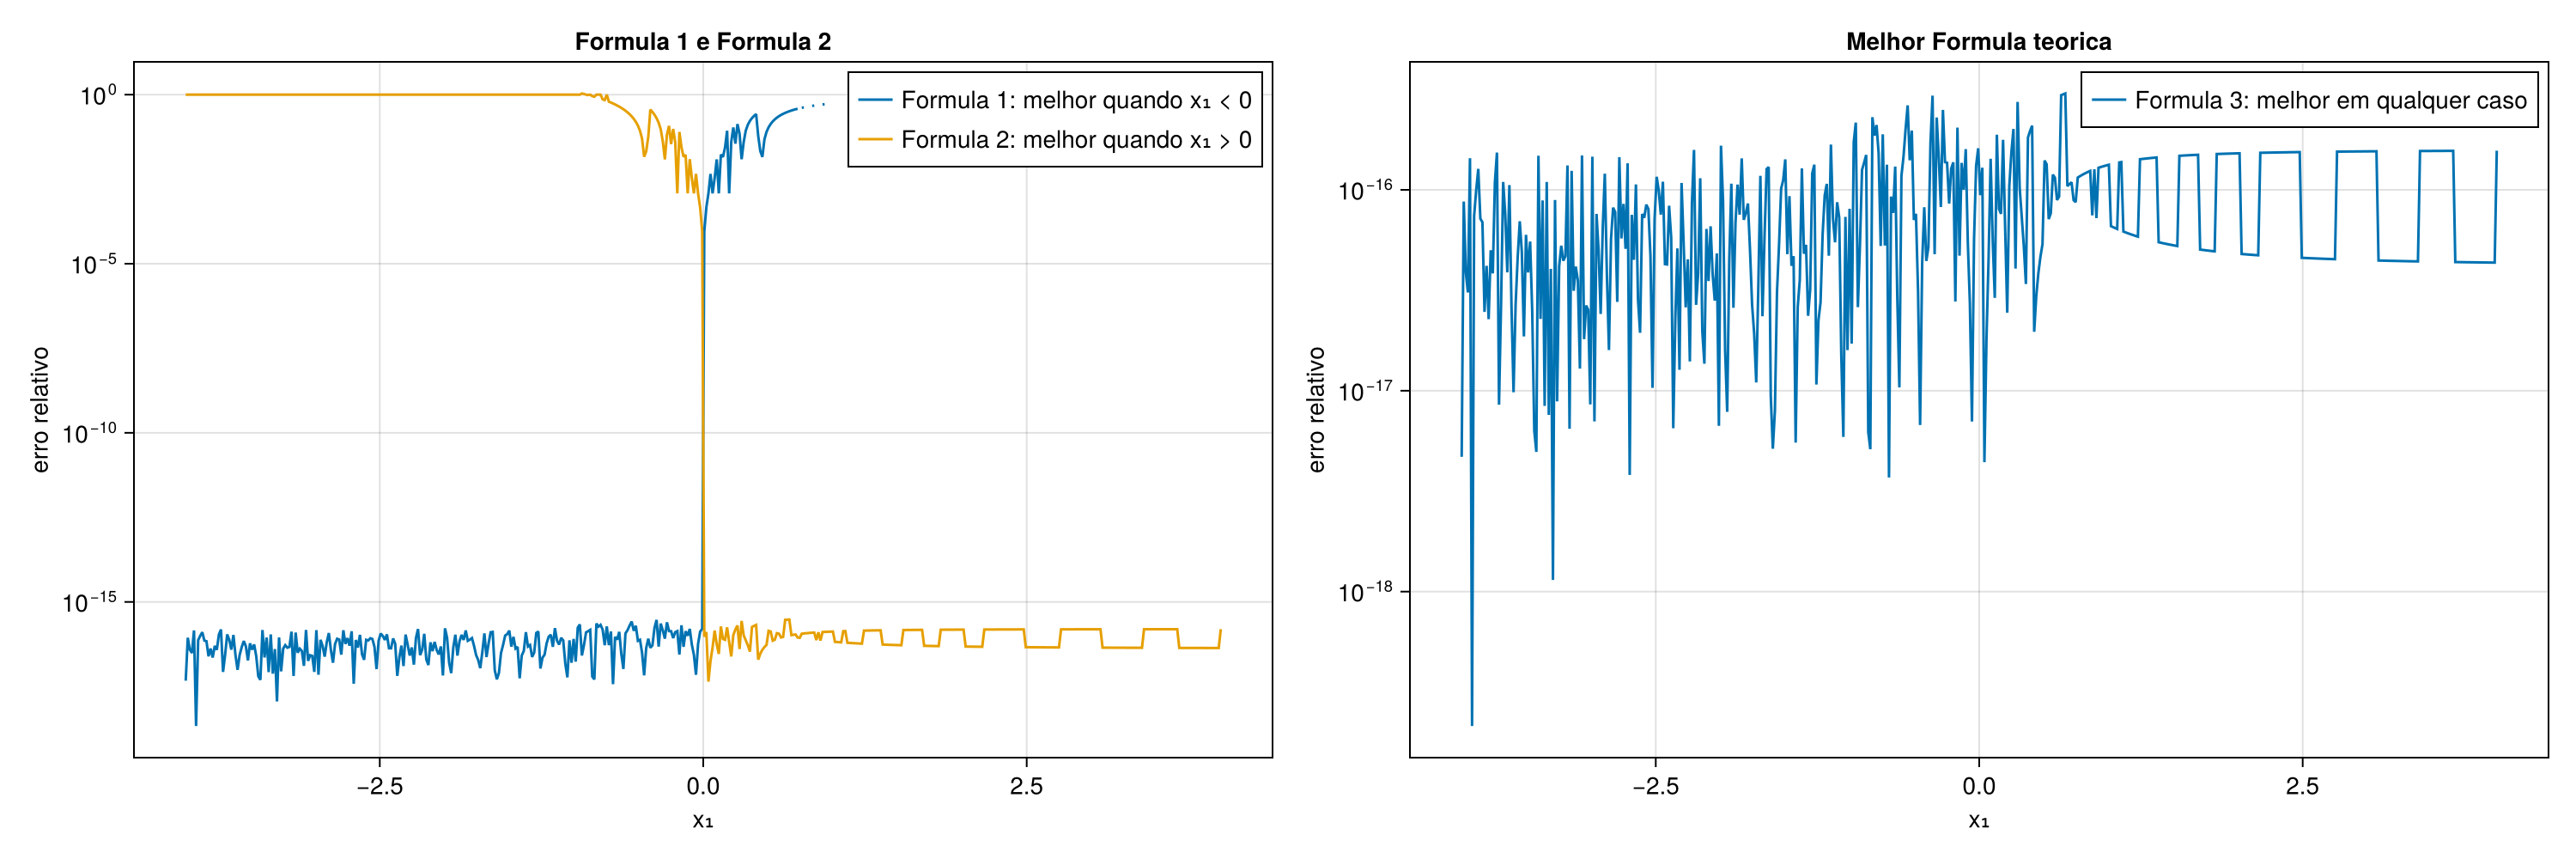

In [90]:
# tenta simular a presição perfeita usando muitas casas decimais
function β_ref(x)
    xb = BigFloat.(x)
    return calc_β(xb)
end

# calcula o erro relativo
function relerr(b_til, b)
    abs(b_til - b) / abs(b)
end

xs = range(-4, 4, length=500)

err1 = similar(xs, Float64)
err2 = similar(xs, Float64)
err3 = similar(xs, Float64)

for (i, x1) in pairs(xs)
    x = [x1, 1e-8]
    βtrue = β_ref(x)

    err1[i] = relerr(calc_β(x; type=:one),  βtrue)
    err2[i] = relerr(calc_β(x; type=:two),  βtrue)
    err3[i] = relerr(calc_β(x; type=:best), βtrue)
end

fig = Figure(size=(1500, 500))

ax1 = Axis(fig[1, 1],yscale=log10 ,title="Formula 1 e Formula 2", xlabel="x₁", ylabel="erro relativo")
ax2 = Axis(fig[1, 2],yscale=log10 ,title="Melhor Formula teorica", xlabel="x₁", ylabel="erro relativo")

lines!(ax1, xs, err1, label="Formula 1: melhor quando x₁ < 0")
lines!(ax1, xs, err2, label="Formula 2: melhor quando x₁ > 0")
lines!(ax2, xs, err3, label="Formula 3: melhor em qualquer caso")

axislegend(ax1, position = :rt)
axislegend(ax2, position = :rt)

fig



## item c)

In [91]:
function reflector(x)
    norm_x = norm(x)

    v = x
    v[1] -= norm_x
    
    β = calc_β(x)

    return v, β
end

reflector (generic function with 1 method)

# Questão 3

## item a)

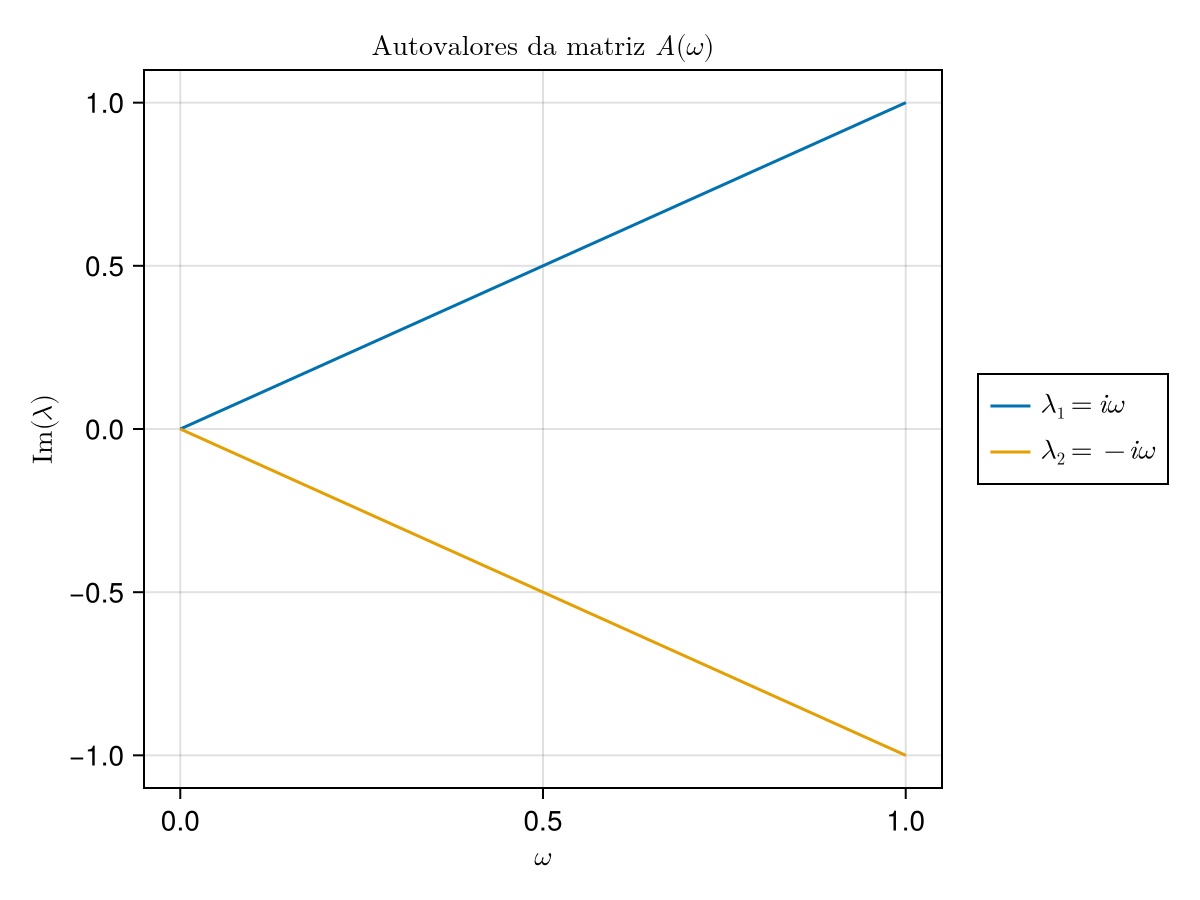

In [46]:
ωs = range(0, 1, length=100)

fig = Figure()
ax = Axis(
    fig[1, 1],
    xlabel = L"\omega",
    ylabel = L"\mathrm{Im}(\lambda)",
    title = L"\text{Autovalores da matriz } A(\omega)"
)

lines!(ax, ωs, ωs,  label=L"\lambda_1 = i\omega")
lines!(ax, ωs, -ωs, label=L"\lambda_2 = -i\omega")

Legend(fig[1,2], ax)

fig

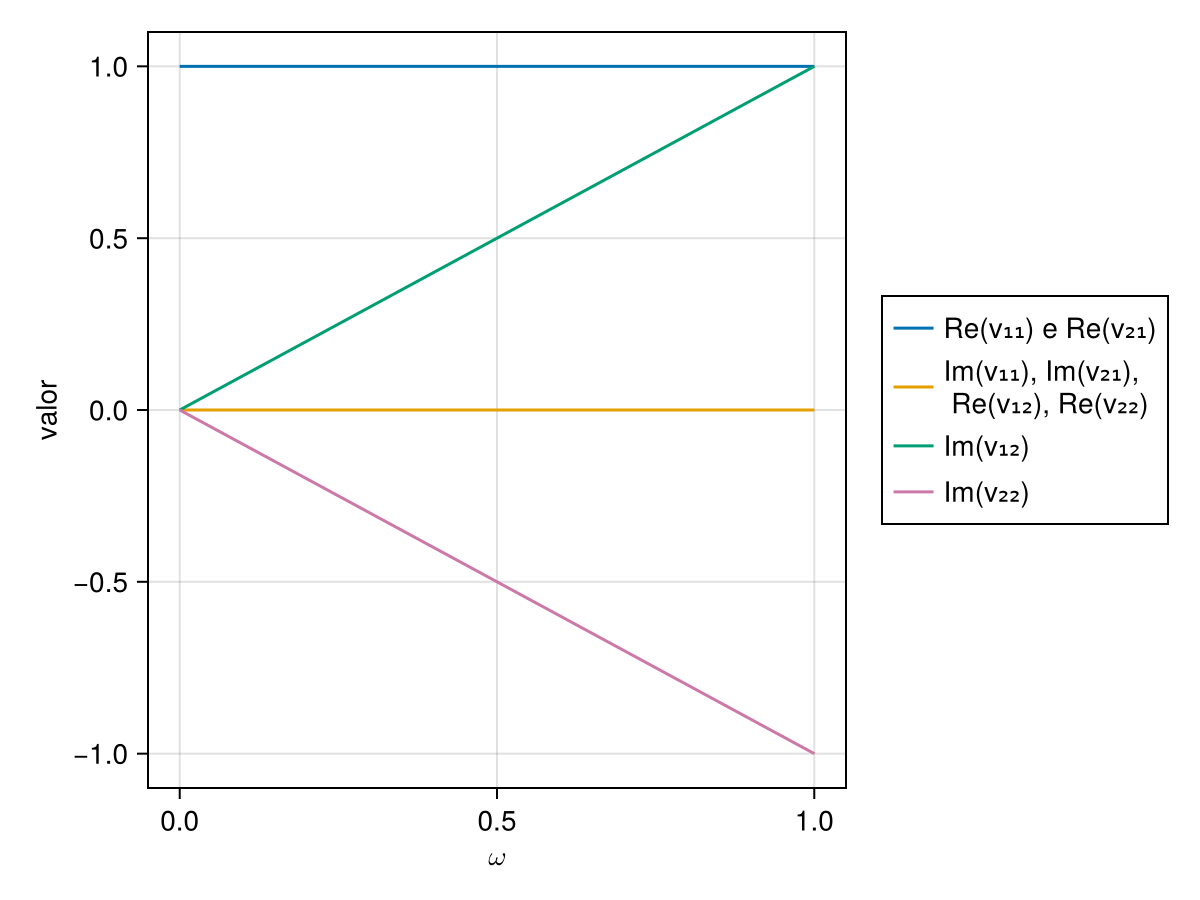

In [64]:
ω = LinRange(0, 1, 100)

v11 = ones(length(ω))
v12 = im .* ω

v21 = v11
v22 = -v12

fig = Figure()

ax1 = Axis(fig[1,1],
    xlabel = L"\omega",
    ylabel = "valor")

lines!(ax1, ω, real.(v11), label = "Re(v₁₁) e Re(v₂₁)")
lines!(ax1, ω, imag.(v11), label = "Im(v₁₁), Im(v₂₁),\n Re(v₁₂), Re(v₂₂)")

lines!(ax1, ω, imag.(v12), label = "Im(v₁₂)")
lines!(ax1, ω, imag.(v22), label = "Im(v₂₂)")



Legend(fig[1, 2], ax1)

fig

## item b)

In [67]:
function A(w)

    return [0 1; -w^2 0]
    
end

A (generic function with 1 method)

In [76]:
first(svdvals(A(0.5)))

1.0